## Key Questions

1. Which business segment closes the most deals?
2. Which lead type has the highest conversion rate?
3. Which behaviour profile is most common among high-revenue sellers?
4. How have deal closures changed over time?
5. Is there a revenue difference between manufacturers and resellers?

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

In [55]:
# ── colour palette ──────────────────────────
PURPLE  = "#7F77DD"
TEAL    = "#1D9E75"
CORAL   = "#D85A30"
AMBER   = "#BA7517"
BLUE    = "#378ADD"
GRAY    = "#888780"
BG      = "#F8F8F6"
TEXT    = "#2C2C2A"

In [56]:
plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor":   BG,
    "axes.edgecolor":   "#D3D1C7",
    "axes.labelcolor":  TEXT,
    "xtick.color":      TEXT,
    "ytick.color":      TEXT,
    "text.color":       TEXT,
    "font.family":      "sans-serif",
    "font.size":        11,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.grid":        True,
    "grid.color":       "#D3D1C7",
    "grid.linewidth":   0.5,
    "grid.alpha":       0.6,
})

In [57]:
df = pd.read_csv('olist_closed_deals_dataset.csv')

In [58]:
# Parse dates
df['won_date'] = pd.to_datetime(df['won_date'])
 
# Extract time features
df['won_month']      = df['won_date'].dt.to_period('M')          # e.g. 2018-03
df['won_month_str']  = df['won_date'].dt.strftime('%b %Y')       # e.g. Mar 2018
df['won_month_num']  = df['won_date'].dt.to_period('M').apply(lambda x: x.ordinal)

In [59]:
df.won_month
# df.won_month_str
# df.won_month_num

0      2018-02
1      2018-05
2      2018-06
3      2018-01
4      2018-07
        ...   
837    2018-08
838    2018-09
839    2018-06
840    2018-03
841    2018-05
Name: won_month, Length: 842, dtype: period[M]

In [60]:
# Clean revenue: 0.0 means "not declared" — treat as NaN for revenue analysis
df['revenue_clean'] = df['declared_monthly_revenue'].replace(0.0, np.nan)
df.revenue_clean

0           NaN
1           NaN
2           NaN
3           NaN
4           NaN
         ...   
837         NaN
838    200000.0
839         NaN
840         NaN
841         NaN
Name: revenue_clean, Length: 842, dtype: float64

In [61]:
# Standardise lead_behaviour_profile: keep only the FIRST value for multi-value rows
# e.g. "eagle, wolf" → "eagle"   (primary profile assigned first)
df['profile_primary'] = df['lead_behaviour_profile'].str.split(',').str[0].str.strip()

df.profile_primary

0        cat
1      eagle
2        cat
3        NaN
4       wolf
       ...  
837      cat
838     wolf
839     wolf
840      cat
841    eagle
Name: profile_primary, Length: 842, dtype: object

In [62]:
# Fill remaining categoricals with 'Unknown' so they don't disappear from charts
df['business_type']      = df['business_type'].fillna('Unknown')
df['business_segment']   = df['business_segment'].fillna('Unknown')
df['lead_type']          = df['lead_type'].fillna('Unknown')
df['profile_primary']    = df['profile_primary'].fillna('Unknown')

In [63]:
# ── Define "high revenue" as sellers with declared monthly revenue above median
#    (among those who actually declared it)
median_rev = df['revenue_clean'].median(skipna=True)
df['is_high_revenue'] = df['revenue_clean'] > median_rev

In [64]:
print("=" * 60)
print("OLIST CLOSED DEALS — ANALYSIS SUMMARY")
print("=" * 60)
print(f"  Total closed deals : {len(df):,}")
print(f"  Date range         : {df['won_date'].min().date()} → {df['won_date'].max().date()}")
print(f"  Revenue median     : R$ {median_rev:,.0f}  (among declared only)")
print(f"  High-revenue leads : {df['is_high_revenue'].sum()} sellers")
print()

OLIST CLOSED DEALS — ANALYSIS SUMMARY
  Total closed deals : 842
  Date range         : 2017-12-05 → 2018-11-14
  Revenue median     : R$ 50,000  (among declared only)
  High-revenue leads : 21 sellers



Q1) Which business_segment has the most closed deals?

────────────────────────────────────────────────────────────
Q1: Business segment with most closed deals
────────────────────────────────────────────────────────────
business_segment
home_decor                         105
health_beauty                       93
car_accessories                     77
household_utilities                 71
construction_tools_house_garden     69
audio_video_electronics             64
computers                           34
pet                                 30
food_supplement                     28
food_drink                          26
sports_leisure                      25
bed_bath_table                      22
  → Saved: q1_business_segment.png



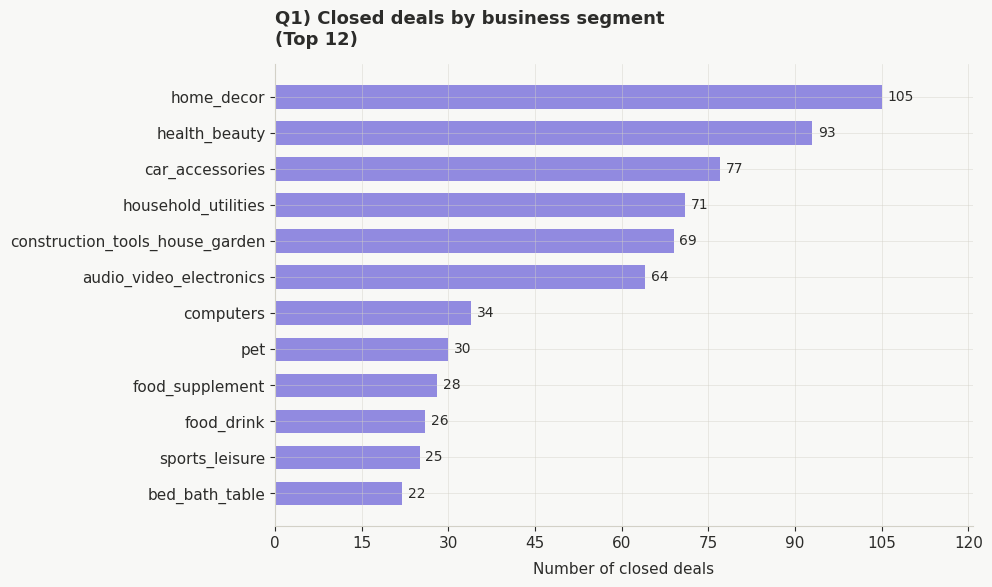

In [65]:
print("─" * 60)
print("Q1: Business segment with most closed deals")
print("─" * 60)

seg_counts = (
    df['business_segment']
    .value_counts()
    .head(12)                  # top 12 for readability
    .sort_values()             # ascending so longest bar is at top in horizontal chart
)

print(seg_counts.sort_values(ascending=False).to_string())
 
fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor(BG)
 
bars = ax.barh(seg_counts.index, seg_counts.values,
               color=PURPLE, alpha=0.85, height=0.65)

# Annotate bar ends with count
for bar, val in zip(bars, seg_counts.values):
    ax.text(val + 1, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=10, color=TEXT)
 
ax.set_xlabel("Number of closed deals", labelpad=8)
ax.set_title("Q1) Closed deals by business segment\n(Top 12)", 
             fontsize=13, fontweight='bold', pad=14, loc='left')
ax.set_xlim(0, seg_counts.max() * 1.15)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))


# plt.tight_layout()
plt.savefig('output/q1_business_segment.png', dpi=150, bbox_inches='tight')
# plt.close()
print("  → Saved: q1_business_segment.png\n")

Q2) Which lead_type converts most often?

In [69]:
print("─" * 60)
print("Q2: Lead type distribution among closed deals")
print("─" * 60)

lt_counts = df['lead_type'].value_counts()
lt_pct    = (lt_counts / lt_counts.sum() * 100).round(1)

for lt, cnt in lt_counts.items():
    print(f"  {lt:<20} {cnt:>4} deals  ({lt_pct[lt]}%)")



────────────────────────────────────────────────────────────
Q2: Lead type distribution among closed deals
────────────────────────────────────────────────────────────
  online_medium         332 deals  (39.4%)
  online_big            126 deals  (15.0%)
  industry              123 deals  (14.6%)
  offline               104 deals  (12.4%)
  online_small           77 deals  (9.1%)
  online_beginner        57 deals  (6.8%)
  online_top             14 deals  (1.7%)
  Unknown                 6 deals  (0.7%)
  other                   3 deals  (0.4%)


  → Saved: q2_lead_type.png



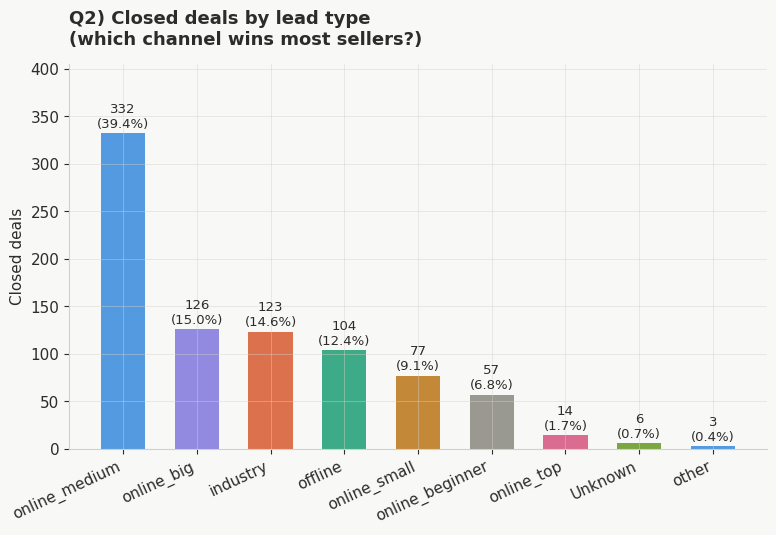

In [71]:
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor(BG)

colors = [BLUE, PURPLE, CORAL, TEAL, AMBER, GRAY, "#D4537E", "#639922"]
bars = ax.bar(lt_counts.index, lt_counts.values,
              color=colors[:len(lt_counts)], alpha=0.85, width=0.6)

for bar, val, pct in zip(bars, lt_counts.values, lt_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
            f"{val}\n({pct}%)", ha='center', va='bottom', fontsize=9.5, color=TEXT)
    
ax.set_ylabel("Closed deals")
ax.set_title("Q2) Closed deals by lead type\n(which channel wins most sellers?)",
             fontsize=13, fontweight='bold', pad=14, loc='left')
ax.set_ylim(0, lt_counts.max() * 1.22)
plt.xticks(rotation=25, ha='right')
 
plt.savefig('output/q2_lead_type.png', dpi=150, bbox_inches='tight')
print("  → Saved: q2_lead_type.png\n")

Q3) Which behaviour profile is most common among high-revenue sellers?

In [72]:
print("─" * 60)
print("Q3: Behaviour profile of high-revenue sellers")
print("─" * 60)

────────────────────────────────────────────────────────────
Q3: Behaviour profile of high-revenue sellers
────────────────────────────────────────────────────────────


  (High revenue = declared monthly revenue > R$ 50,000)
  cat          total= 415  high-revenue=  8  (1.9%)
  eagle        total= 129  high-revenue=  1  (0.8%)
  shark        total=  26  high-revenue=  4  (15.4%)
  wolf         total=  95  high-revenue=  7  (7.4%)
  → Saved: q3_behaviour_profile.png



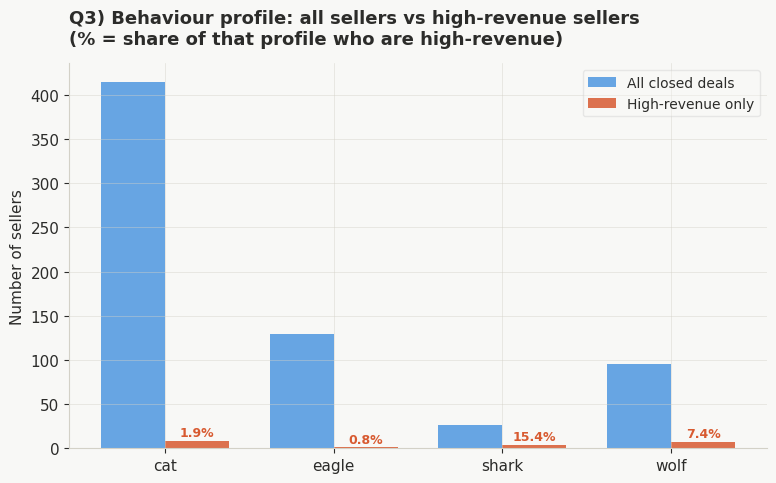

In [82]:
# Split into high-revenue and normal groups, count profiles in each
profile_all  = df['profile_primary'].value_counts()
profile_high = df[df['is_high_revenue']]['profile_primary'].value_counts()

# Align both series to the same index
all_profiles = sorted(set(profile_all.index) | set(profile_high.index))
all_profiles = [p for p in all_profiles if p != 'Unknown']

counts_all  = [profile_all.get(p, 0)  for p in all_profiles]
counts_high = [profile_high.get(p, 0) for p in all_profiles]
 
# Percentage of each profile that is high-revenue
pct_high = [
    round(h / a * 100, 1) if a > 0 else 0
    for h, a in zip(counts_high, counts_all)
]

print(f"  (High revenue = declared monthly revenue > R$ {median_rev:,.0f})")
for p, a, h, pct in zip(all_profiles, counts_all, counts_high, pct_high):
    print(f"  {p:<12} total={a:>4}  high-revenue={h:>3}  ({pct}%)")

x = np.arange(len(all_profiles))
width = 0.38

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor(BG)
 
b1 = ax.bar(x - width/2, counts_all,  width, label='All closed deals', color=BLUE,  alpha=0.75)
b2 = ax.bar(x + width/2, counts_high, width, label='High-revenue only', color=CORAL, alpha=0.85)
 
# Add % labels on top of high-revenue bars
for bar, pct in zip(b2, pct_high):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
            f"{pct}%", ha='center', va='bottom', fontsize=9, color=CORAL, fontweight='bold')
 
ax.set_xticks(x)
ax.set_xticklabels(all_profiles, fontsize=11)
ax.set_ylabel("Number of sellers")
ax.set_title("Q3) Behaviour profile: all sellers vs high-revenue sellers\n(% = share of that profile who are high-revenue)",
             fontsize=13, fontweight='bold', pad=14, loc='left')
ax.legend(framealpha=0.4, fontsize=10)
 
plt.savefig('output/q3_behaviour_profile.png', dpi=150, bbox_inches='tight')
print("  → Saved: q3_behaviour_profile.png\n")
 





Q4) Is there a growth trend in monthly deal closures?

────────────────────────────────────────────────────────────
Q4: Month-over-month growth in closed deals
────────────────────────────────────────────────────────────
won_month_str  deals  mom_change
     Dec 2017      3         NaN
     Jan 2018     73 2333.333333
     Feb 2018    113   54.794521
     Mar 2018    147   30.088496
     Apr 2018    207   40.816327
     May 2018    122  -41.062802
     Jun 2018     57  -53.278689
     Jul 2018     37  -35.087719
     Aug 2018     33  -10.810811
     Sep 2018     23  -30.303030
     Oct 2018     21   -8.695652
     Nov 2018      6  -71.428571
  → Saved: q4_monthly_trend.png



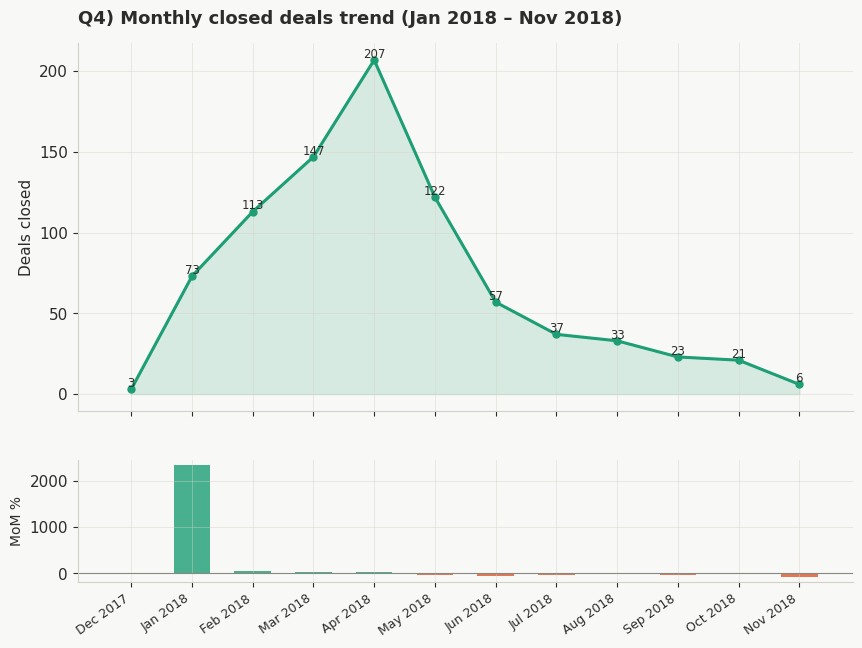

In [86]:
print("─" * 60)
print("Q4: Month-over-month growth in closed deals")
print("─" * 60)
 
monthly = (
    df.groupby('won_month')
    .size()
    .reset_index(name='deals')
    .sort_values('won_month')
)


monthly['won_month_str'] = monthly['won_month'].dt.strftime('%b %Y')

# Month-over-month % change
monthly['mom_change'] = monthly['deals'].pct_change() * 100
 
print(monthly[['won_month_str', 'deals', 'mom_change']].to_string(index=False))
 
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1]})
fig.patch.set_facecolor(BG)
 
# Top: line + area
ax1.fill_between(range(len(monthly)), monthly['deals'],
                 alpha=0.15, color=TEAL)
ax1.plot(range(len(monthly)), monthly['deals'],
         color=TEAL, linewidth=2.2, marker='o', markersize=5)
 
for i, row in monthly.iterrows():
    idx = list(monthly.index).index(i)
    ax1.text(idx, row['deals'] + 1.5, str(row['deals']),
             ha='center', fontsize=8.5, color=TEXT)
 
ax1.set_ylabel("Deals closed")
ax1.set_title("Q4) Monthly closed deals trend (Jan 2018 – Nov 2018)",
              fontsize=13, fontweight='bold', pad=14, loc='left')
 
# Bottom: MoM bars
colors_mom = [TEAL if v >= 0 else CORAL for v in monthly['mom_change'].fillna(0)]
ax2.bar(range(len(monthly)), monthly['mom_change'].fillna(0),
        color=colors_mom, alpha=0.8, width=0.6)
ax2.axhline(0, color=GRAY, linewidth=0.8)
ax2.set_ylabel("MoM %", fontsize=10)
 
ax2.set_xticks(range(len(monthly)))
ax2.set_xticklabels(monthly['won_month_str'], rotation=35, ha='right', fontsize=9)

plt.savefig('output/q4_monthly_trend.png', dpi=150, bbox_inches='tight')
print("  → Saved: q4_monthly_trend.png\n")

Q5) Do manufacturers vs resellers differ in declared revenue?

────────────────────────────────────────────────────────────
Q5: Declared revenue — manufacturers vs resellers
────────────────────────────────────────────────────────────
  Rows with declared revenue: 42

               count       mean         std     min      25%       50%       75%         max
business_type                                                                               
manufacturer     7.0  7260714.0  18846545.0  5000.0  75000.0  120000.0  275000.0  50000000.0
reseller        35.0   295229.0   1342909.0     6.0  15000.0   30000.0  100000.0   8000000.0
  → Saved: q5_revenue_comparison.png



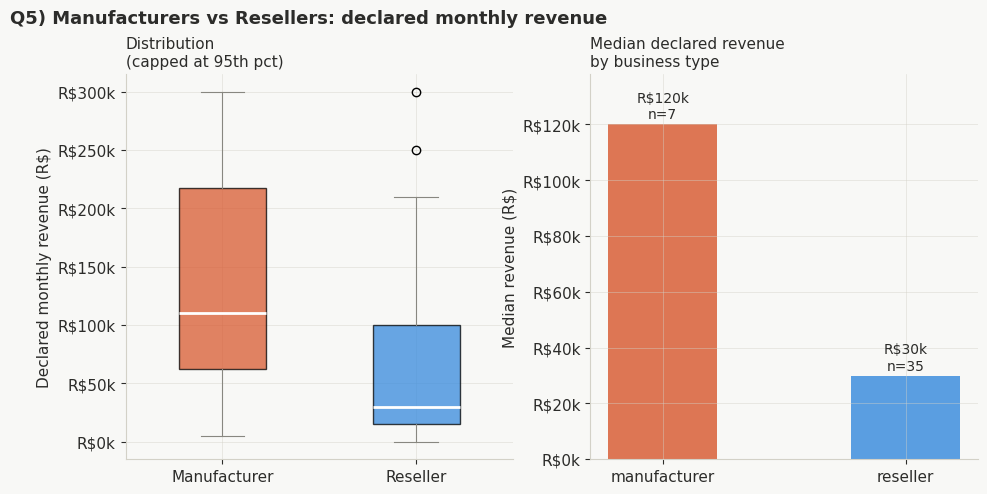

In [91]:
print("─" * 60)
print("Q5: Declared revenue — manufacturers vs resellers")
print("─" * 60)
 
# Only compare manufacturers and resellers (enough data); exclude 'other' and 'Unknown'
rev_df = df[
    (df['revenue_clean'].notna()) &
    (df['business_type'].isin(['manufacturer', 'reseller']))
][['business_type', 'revenue_clean']].copy()
 
print(f"  Rows with declared revenue: {len(rev_df)}")
print()
print(rev_df.groupby('business_type')['revenue_clean'].describe().round(0).to_string())
 
# Cap extreme outliers for visualisation (use 95th percentile cap)
cap = rev_df['revenue_clean'].quantile(0.95)
rev_plot = rev_df[rev_df['revenue_clean'] <= cap].copy()
 
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
fig.patch.set_facecolor(BG)
 
# Left: box plot
groups = [
    rev_plot[rev_plot['business_type'] == 'manufacturer']['revenue_clean'].values,
    rev_plot[rev_plot['business_type'] == 'reseller']['revenue_clean'].values,
]
bp = axes[0].boxplot(groups, labels=['Manufacturer', 'Reseller'],
                     patch_artist=True, widths=0.45,
                     medianprops=dict(color='white', linewidth=2))
bp['boxes'][0].set_facecolor(CORAL)
bp['boxes'][0].set_alpha(0.75)
bp['boxes'][1].set_facecolor(BLUE)
bp['boxes'][1].set_alpha(0.75)
for w in bp['whiskers'] + bp['caps'] + bp['fliers']:
    w.set(color=GRAY, linewidth=0.8)
 
axes[0].set_ylabel("Declared monthly revenue (R$)")
axes[0].set_title("Distribution\n(capped at 95th pct)", fontsize=11, loc='left')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x/1000:.0f}k"))
 
# Right: median bar chart with counts
summary = rev_df.groupby('business_type')['revenue_clean'].agg(
    median='median', mean='mean', count='count'
).loc[['manufacturer', 'reseller']]
 
bar_colors = [CORAL, BLUE]
bars = axes[1].bar(summary.index, summary['median'],
                   color=bar_colors, alpha=0.82, width=0.45)
 
max_val = summary['median'].max()
axes[1].set_ylim(0, max_val * 1.15)

for bar, (btype, row) in zip(bars, summary.iterrows()):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1000,
                 f"R${row['median']/1000:.0f}k\nn={int(row['count'])}",
                 ha='center', va='bottom', fontsize=10, color=TEXT)
 
axes[1].set_ylabel("Median revenue (R$)")
axes[1].set_title("Median declared revenue\nby business type", fontsize=11, loc='left')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x/1000:.0f}k"))
 
fig.suptitle("Q5) Manufacturers vs Resellers: declared monthly revenue",
             fontsize=13, fontweight='bold', y=1.01, x=0.02, ha='left')
 
plt.savefig('output/q5_revenue_comparison.png', dpi=150, bbox_inches='tight')
print("  → Saved: q5_revenue_comparison.png\n")

FINAL PRINTED SUMMARY

In [93]:
top_seg   = df['business_segment'].value_counts().idxmax()
top_seg_n = df['business_segment'].value_counts().max()
 
top_lt    = df['lead_type'].value_counts().idxmax()
top_lt_n  = df['lead_type'].value_counts().max()
 
top_prof  = df[df['is_high_revenue']]['profile_primary'].value_counts().idxmax()
 
best_month     = monthly.loc[monthly['deals'].idxmax(), 'won_month_str']
best_month_cnt = monthly['deals'].max()
 
mfr_med = rev_df[rev_df['business_type']=='manufacturer']['revenue_clean'].median()
res_med = rev_df[rev_df['business_type']=='reseller']['revenue_clean'].median()
 
print(f"""
  Q1 → Top segment   : {top_seg} ({top_seg_n} deals)
  Q2 → Top lead type : {top_lt} ({top_lt_n} deals, {round(top_lt_n/len(df)*100,1)}% of all wins)
  Q3 → High-revenue profile : {top_prof} is most common
  Q4 → Peak month    : {best_month} ({best_month_cnt} deals)
  Q5 → Manufacturers declare R${mfr_med:,.0f} median revenue
       Resellers declare     R${res_med:,.0f} median revenue
       Manufacturers declare {round(mfr_med/res_med, 1)}x more revenue on average
""")
print("All 5 charts saved to /output/")


  Q1 → Top segment   : home_decor (105 deals)
  Q2 → Top lead type : online_medium (332 deals, 39.4% of all wins)
  Q3 → High-revenue profile : cat is most common
  Q4 → Peak month    : Apr 2018 (207 deals)
  Q5 → Manufacturers declare R$120,000 median revenue
       Resellers declare     R$30,000 median revenue
       Manufacturers declare 4.0x more revenue on average

All 5 charts saved to /output/
